<a href="https://colab.research.google.com/github/Kofi360/npontu-ecommerce-behavior-analysis-/blob/main/01_ecommerce_analytics_master.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NPONTU TECHNOLOGIES INTERVIEW ASSESSMENT
Position: Intelligent Systems Services Engineer(NSS)
Assignment Title: Analyzing Customer Behavior for E-commerce Insights
Candidate Name: Nana Kofi Antwi Boasiako

In [1]:
!pip install faker imbalanced-learn xgboost scikit-learn pandas numpy matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 24.9 MB/s eta 0:00:00


Section 1: Synthetic Data Generation
We generate a synthetic dataset representing customer activity, demographics, and transactional behavior. To test data cleansing robustness, we explicitly introduce missing values (~5%), erroneous records (negative purchase amounts, unrealistic ages), and duplicate entries.

      

In [3]:
from datetime import datetime, timedelta
import random
from faker import Faker
import numpy as np
import pandas as pd

# Set seeds for deterministic reproducibility
np.random.seed(42)
random.seed(42)
fake = Faker()

def generate_synthetic_ecommerce_data(num_records: int = 20000) -> pd.DataFrame:
    regions = [
        "Greater Accra",
        "Ashanti",
        "Western",
        "Central",
        "Eastern",
        "Northern",
    ]
    categories = [
        "Electronics",
        "Fashion",
        "Home & Kitchen",
        "Beauty & Health",
        "Mobile Accessories",
    ]
    devices = ["Mobile_iOS", "Mobile_Android", "Desktop_Windows", "Desktop_MacOS"]
    payment_methods = [
        "Mobile Money (MTN/Telecel)",
        "Credit Card",
        "Bank Transfer",
        "Cash on Delivery",
    ]

    customer_pool = [f"CUST_{1000 + i}" for i in range(2500)]
    start_date = datetime(2024, 1, 1)

    data = []
    for i in range(num_records):
        cust_id = random.choice(customer_pool)
        age = np.random.choice(
            [random.randint(18, 70), -5, 150, np.nan], p=[0.92, 0.03, 0.02, 0.03]
        )
        gender = np.random.choice(
            ["Male", "Female", "Non-Binary", None], p=[0.48, 0.48, 0.01, 0.03]
        )
        region = random.choice(regions)
        signup_dt = start_date + timedelta(days=random.randint(0, 300))

        session_id = f"SESS_{100000 + i}"
        duration_pages = max(1, int(np.random.gamma(shape=2, scale=3)))
        prod_cat = random.choice(categories)
        device = random.choice(devices)
        cart_adds = int(np.random.poisson(lam=1.5))

        order_id = f"ORD_{500000 + i}"
        purchase_amt = np.random.choice(
            [round(np.random.exponential(scale=150.0) + 10.0, 2), -150.0, 0.0],
            p=[0.94, 0.03, 0.03],
        )
        pay_method = random.choice(payment_methods)
        order_dt = signup_dt + timedelta(
            days=random.randint(0, 180), minutes=random.randint(0, 1440)
        )
        discount = np.random.choice([0.0, 0.10, 0.15, 0.25], p=[0.6, 0.2, 0.1, 0.1])

        satisfaction = np.random.choice(
            [1, 2, 3, 4, 5, None], p=[0.1, 0.15, 0.25, 0.3, 0.15, 0.05]
        )
        churn_prob = (
            0.15
            + (0.25 if cart_adds == 0 else 0.0)
            + (0.3 if purchase_amt <= 0 else 0.0)
        )
        churn_label = 1 if random.random() < min(churn_prob, 0.85) else 0

        data.append(
            {
                "customer_id": cust_id,
                "age": age,
                "gender": gender,
                "region": region,
                "signup_date": signup_dt.strftime("%Y-%m-%d"),
                "session_id": session_id,
                "duration_pages": duration_pages,
                "product_category": prod_cat,
                "device_type": device,
                "cart_additions": cart_adds,
                "order_id": order_id,
                "purchase_amount": purchase_amt,
                "payment_method": pay_method,
                "order_date": order_dt.strftime("%Y-%m-%d %H:%M:%S"),
                "discount_applied": discount,
                "churn_label": churn_label,
                "customer_satisfaction_score": satisfaction,
            }
        )

    df = pd.DataFrame(data)

    # Introduce duplicate records (~3%)
    dup_indices = df.sample(frac=0.03, random_state=42).index
    df = pd.concat([df, df.loc[dup_indices]], ignore_index=True)

    return df

# Generate and preview dataset
raw_df = generate_synthetic_ecommerce_data(num_records=20000)
print(f"Dataset Generated Successfully. Raw Shape: {raw_df.shape}")
raw_df.head()

Dataset Generated Successfully. Raw Shape: (20600, 17)


,customer_id,age,gender,region,signup_date,session_id,duration_pages,product_category,device_type,cart_additions,order_id,purchase_amount,payment_method,order_date,discount_applied,churn_label,customer_satisfaction_score
0,CUST_1456,19.0,Female,Northern,2024-05-20,SESS_100000,7,Fashion,Mobile_Android,0,ORD_500000,18.98,Credit Card,2024-06-15 23:05:00,0.10,0,4.0
1,CUST_3233,23.0,Non-Binary,Eastern,2024-08-04,SESS_100001,13,Electronics,Mobile_iOS,0,ORD_500001,40.10,Mobile Money (MTN/Telecel),2024-09-28 07:56:00,0.00,0,4.0
2,CUST_1108,53.0,Male,Ashanti,2024-10-06,SESS_100002,2,Beauty & Health,Mobile_Android,1,ORD_500002,240.69,Cash on Delivery,2025-03-05 09:29:00,0.00,0,4.0
3,CUST_1026,66.0,Female,Ashanti,2024-08-04,SESS_100003,6,Home & Kitchen,Desktop_Windows,0,ORD_500003,-150.00,Credit Card,2024-09-28 11:29:00,0.15,1,3.0
4,CUST_2556,24.0,Female,Western,2024-06-25,SESS_100004,1,Mobile Accessories,Desktop_Windows,0,ORD_500004,370.06,Mobile Money (MTN/Telecel),2024-10-20 18:18:00,0.10,1,3.0


Section 2: Exploratory Data Analysis & Cleaning
1. Deduplication: Remove exact record duplicates.
2. Age Sanity Rules: Remove out-of-bounds human ages (<18 or >100) and impute missing values using regional medians.
3. Financial Anomalies: Remove corrupted negative purchase entries (purchase_amount <= 0).


In [6]:
def clean_ecommerce_data(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = df.copy()

    # Deduplication
    cleaned = cleaned.drop_duplicates().reset_index(drop=True)

    # Correct Erroneous Ages
    cleaned.loc[(cleaned["age"] < 18) | (cleaned["age"] > 100), "age"] = np.nan
    cleaned["age"] = cleaned.groupby("region")["age"].transform(
        lambda x: x.fillna(x.median())
    )
    cleaned["age"] = cleaned["age"].fillna(cleaned["age"].median())

    # Handle Erroneous Monetary Values
    cleaned = cleaned[cleaned["purchase_amount"] > 0].reset_index(drop=True)

    # Fill Categorical Missing Values
    cleaned["gender"] = cleaned["gender"].fillna("Unknown")
    cleaned["customer_satisfaction_score"] = cleaned[
        "customer_satisfaction_score"
    ].fillna(cleaned["customer_satisfaction_score"].median())

    # Parse Datetime columns
    cleaned["order_date"] = pd.to_datetime(cleaned["order_date"])
    cleaned["signup_date"] = pd.to_datetime(cleaned["signup_date"])

    return cleaned

df_clean = clean_ecommerce_data(raw_df)
print(f"Cleansing Complete. Remaining valid rows: {len(df_clean)}")

Cleansing Complete. Remaining valid rows: 18829


Section 3: Feature Engineering
We transform point-in-time transactions into aggregate customer profiles:
• RFM Metrics: Recency, Frequency, Monetary value.
• Behavioral Ratios: Cart add-to-purchase ratio and discount reliance index.

In [9]:
def engineer_customer_features(
    df: pd.DataFrame, observation_date: datetime
) -> pd.DataFrame:
    rfm_df = (
        df.groupby("customer_id")
        .agg(
            recency=(
                "order_date",
                lambda x: (observation_date - x.max()).days,
            ),
            frequency=("order_id", "nunique"),
            monetary=("purchase_amount", "sum"),
            avg_basket_size=("purchase_amount", "mean"),
            total_cart_additions=("cart_additions", "sum"),
            avg_session_pages=("duration_pages", "mean"),
            discount_reliance=(
                "discount_applied",
                lambda x: (x > 0).mean(),
            ),
            customer_lifetime_days=(
                "signup_date",
                lambda x: (observation_date - x.min()).days,
            ),
            churn_label=("churn_label", "max"),
            age=("age", "first"),
            gender=("gender", "first"),
            region=("region", "first"),
        )
        .reset_index()
    )

    rfm_df["cart_add_to_purchase_ratio"] = rfm_df["total_cart_additions"] / (
        rfm_df["frequency"] + 1e-5
    )
    rfm_df["avg_daily_spend"] = rfm_df["monetary"] / (
        rfm_df["customer_lifetime_days"] + 1
    )

    return rfm_df

obs_date = df_clean["order_date"].max() + timedelta(days=1)
customer_features = engineer_customer_features(df_clean, obs_date)
print(
    f"Engineered {customer_features.shape[1]} features for {customer_features.shape[0]} unique customers."
)
customer_features.head()

Engineered 15 features for 2500 unique customers.


,customer_id,recency,frequency,monetary,avg_basket_size,total_cart_additions,avg_session_pages,discount_reliance,customer_lifetime_days,churn_label,age,gender,region,cart_add_to_purchase_ratio,avg_daily_spend
0,CUST_1000,104,2,215.70,107.850000,7,5.000000,0.500000,403,1,44.0,Male,Ashanti,3.499983,0.533911
1,CUST_1001,43,11,2296.10,208.736364,21,7.363636,0.454545,453,1,50.0,Male,Eastern,1.909089,5.057489
2,CUST_1002,113,8,953.67,119.208750,9,6.250000,0.250000,409,1,44.0,Female,Western,1.124999,2.326024
3,CUST_1003,83,6,604.02,100.670000,12,4.833333,0.333333,442,1,20.0,Male,Central,1.999997,1.363476
4,CUST_1004,59,3,313.48,104.493333,3,4.666667,0.333333,437,0,21.0,Male,Northern,0.999997,0.715708


Section 4: Predictive Churn Modeling & Evaluation
We build a Random Forest Classifier trained to predict churn risk while using SMOTE to handle imbalanced customer classes.

In [10]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate Features and Target
X = customer_features.drop(columns=["customer_id", "churn_label"])
y = customer_features["churn_label"]

# One-Hot Encode Categorical Variables
X_encoded = pd.get_dummies(X, columns=["gender", "region"], drop_first=True)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
X_encoded, y, test_size=0.20, random_state=42, stratify=y
)

# Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Oversample Imbalanced Class using SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# Fit Random Forest Model
model = RandomForestClassifier(n_estimators=150, max_depth=8, random_state=42)
model.fit(X_train_res, y_train_res)

# Predictions & Metrics
test_preds = model.predict(X_test_scaled)
test_probs = model.predict_proba(X_test_scaled)[:, 1]

print("=== Holdout Test Classification Report ===")
print(classification_report(y_test, test_preds))
print(f"ROC-AUC Score: {roc_auc_score(y_test, test_probs):.4f}")


=== Holdout Test Classification Report ===
              precision    recall  f1-score   support

           0       0.34      0.52      0.41       108
           1       0.85      0.73      0.78       392

    accuracy                           0.68       500
   macro avg       0.59      0.62      0.60       500
weighted avg       0.74      0.68      0.70       500

ROC-AUC Score: 0.6686


Section 5: Model Drivers & Feature Importance

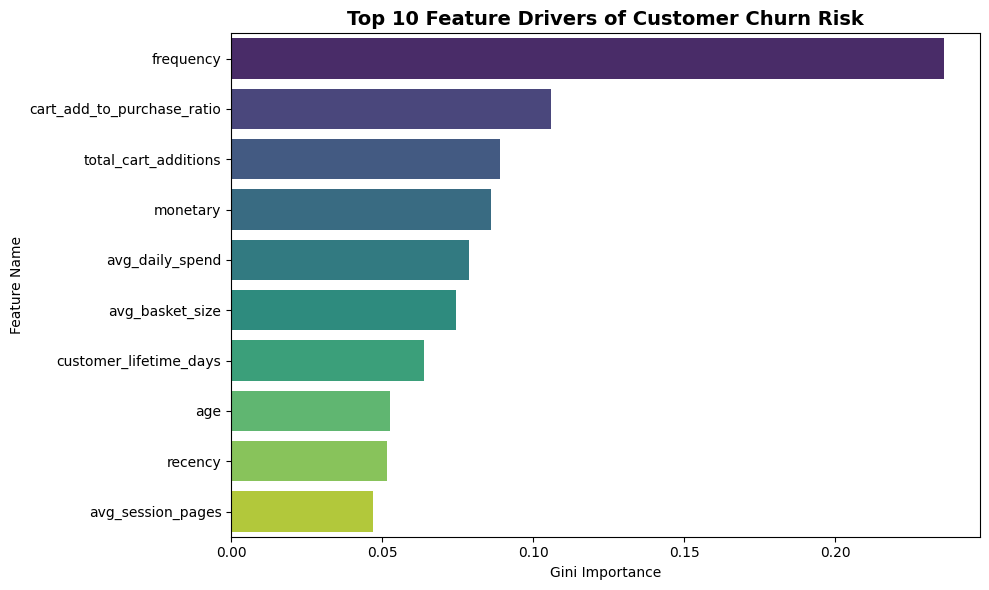

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_names = X_encoded.columns
importances = model.feature_importances_
importance_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": importances}
).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False,
)
plt.title(
    "Top 10 Feature Drivers of Customer Churn Risk",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Gini Importance")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()